# IMDB Sentiment Analysis with Supervised Learning

This notebook applies a supervised learning model to classify IMDB movie reviews as **positive** or **negative**.

## Project Question

Can we predict whether an IMDB movie review is positive or negative based only on the text of the review?

## Supervised Learning Setup

- **Problem type:** Binary classification
- **Input data:** Movie review text
- **Label:** Sentiment (`positive` or `negative`)
- **Model:** Logistic Regression with TF-IDF text features
- **Evaluation:** Accuracy, precision, recall, F1-score, and confusion matrix

## Dataset

This notebook expects the Kaggle file `IMDB Dataset.csv` to be placed in:

```text
data/IMDB Dataset.csv
```

The dataset itself is not included in this repository/notebook package because it should be downloaded directly from Kaggle.


## 1. Import Libraries

These libraries handle data loading, text cleaning, model training, evaluation, and figure/table export.


In [1]:
import os
import re
import html
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_colwidth", 160)


## 2. Set File Paths

Create folders for data and output files.

Place your Kaggle CSV in the `data/` folder before running the notebook.


In [2]:
DATA_PATH = "data/IMDB Dataset.csv"
OUTPUT_DIR = "outputs"

os.makedirs("data", exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Expected dataset path: {DATA_PATH}")
print(f"Outputs will be saved to: {OUTPUT_DIR}/")


Expected dataset path: data/IMDB Dataset.csv
Outputs will be saved to: outputs/


## 3. Load the Dataset

The dataset should contain two main columns:

- `review`: the text of the movie review
- `sentiment`: the ground-truth label, either `positive` or `negative`


In [4]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. "
        "Download the IMDB Dataset of 50K Movie Reviews from Kaggle, "
        "then place 'IMDB Dataset.csv' inside the data/ folder."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (50000, 2)


,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<b...",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomf...",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. Th...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. This is a mov...",positive


## 4. Inspect the Dataset

Before training a model, check the columns, missing values, and sentiment label distribution.


In [5]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())


Columns:
['review', 'sentiment']

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB
None

Missing values:
review       0
sentiment    0
dtype: int64

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


## 5. Visualize Class Balance

This chart shows whether the dataset has roughly equal numbers of positive and negative reviews.

A balanced dataset makes accuracy easier to interpret, while an imbalanced dataset may require closer attention to precision, recall, and F1-score.


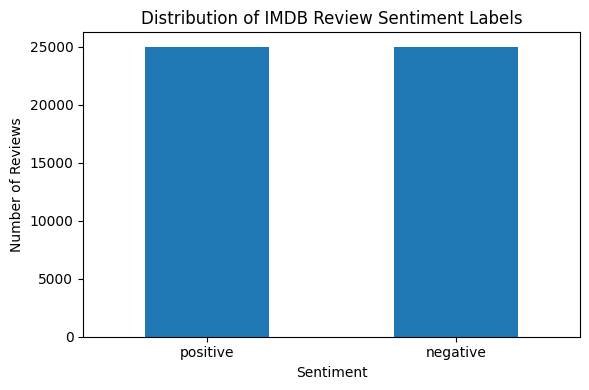

In [6]:
class_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Distribution of IMDB Review Sentiment Labels")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "class_balance.png"), dpi=300)
plt.show()


## 6. Clean the Review Text

The reviews may contain HTML line breaks such as `<br />`. This function removes HTML, lowercases text, and normalizes extra whitespace.

This notebook intentionally avoids overly aggressive cleaning because words like **not**, **never**, and **but** can be important for sentiment analysis.


In [7]:
def clean_review(text):
    """
    Basic text cleaning for IMDB reviews.

    Steps:
    - Remove HTML tags
    - Decode HTML entities
    - Lowercase text
    - Normalize whitespace
    """
    text = BeautifulSoup(str(text), "html.parser"). get_text(separator=" ")
    text = html.unescape(text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text


df["clean_review"] = df["review"].apply(clean_review)

display(df[["review", "clean_review", "sentiment"]].head())


,review,clean_review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<b...","one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me. t...",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomf...","a wonderful little production. the filming technique is very unassuming- very old-time-bbc fashion and gives a comforting, and sometimes discomforting, sens...",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. Th...","i thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. th...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is...,basically there's a family where a little boy (jake) thinks there's a zombie in his closet & his parents are fighting all the time. this movie is slower tha...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. This is a mov...","petter mattei's ""love in the time of money"" is a visually stunning film to watch. mr. mattei offers us a vivid portrait about human relations. this is a mov...",positive


## 7. Encode the Label

The original labels are text values:

- `negative`
- `positive`

For modeling, they are converted to numeric labels:

- `negative` → `0`
- `positive` → `1`


In [8]:
df["label"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

if df["label"].isnull().any():
    raise ValueError("Some sentiment labels could not be mapped to numeric values.")

display(df[["sentiment", "label"]].head())


,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


## 8. Add Simple Analysis Features

These features are not required for the TF-IDF model, but they are useful for understanding the data and discussing possible model errors.


In [9]:
df["review_length_words"] = df["clean_review"].apply(lambda x: len(x.split()))
df["review_length_chars"] = df["clean_review"].apply(len)

display(df[["clean_review", "review_length_words", "review_length_chars", "sentiment"]].head())


,clean_review,review_length_words,review_length_chars,sentiment
0,"one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me. t...",304,1728,positive
1,"a wonderful little production. the filming technique is very unassuming- very old-time-bbc fashion and gives a comforting, and sometimes discomforting, sens...",156,962,positive
2,"i thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. th...",164,904,positive
3,basically there's a family where a little boy (jake) thinks there's a zombie in his closet & his parents are fighting all the time. this movie is slower tha...,135,715,negative
4,"petter mattei's ""love in the time of money"" is a visually stunning film to watch. mr. mattei offers us a vivid portrait about human relations. this is a mov...",225,1272,positive


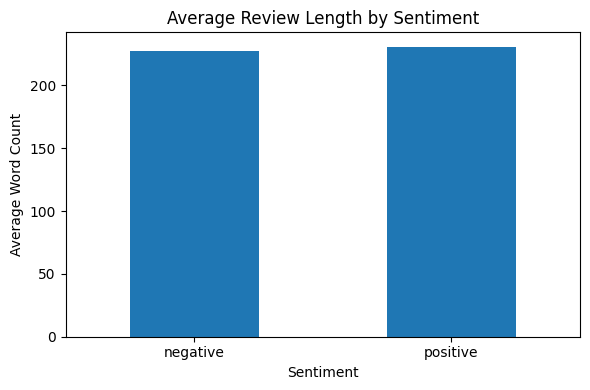

sentiment
negative    227.11444
positive    230.62288
Name: review_length_words, dtype: float64

In [10]:
avg_length = df.groupby("sentiment")["review_length_words"].mean().sort_index()

plt.figure(figsize=(6, 4))
avg_length.plot(kind="bar")
plt.title("Average Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Word Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "avg_review_length_by_sentiment.png"), dpi=300)
plt.show()

avg_length


## 9. Split into Training and Testing Sets

The model is trained on 80% of the data and evaluated on the remaining 20%.

The split is stratified so that the positive/negative distribution stays similar in both sets.


In [11]:
X = df["clean_review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

print("\nTraining label distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting label distribution:")
print(y_test.value_counts(normalize=True))


Training rows: 40000
Testing rows: 10000

Training label distribution:
label
1    0.5
0    0.5
Name: proportion, dtype: float64

Testing label distribution:
label
0    0.5
1    0.5
Name: proportion, dtype: float64


## 10. Build the Model

This project uses a pipeline with two steps:

1. **TF-IDF Vectorizer:** converts review text into numeric word/phrase features.
2. **Logistic Regression:** predicts whether each review is positive or negative.

This is a strong baseline model for text classification because it is simple, fast, and relatively interpretable.


In [12]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=10000,
        ngram_range=(1, 2),
        min_df=5
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## 11. Train the Model


In [13]:
model.fit(X_train, y_train)
print("Model training complete.")


Model training complete.


## 12. Evaluate the Model

The model is evaluated on the test set, which contains reviews the model did not see during training.


In [14]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [accuracy, precision, recall, f1]
})

metrics_df["Score"] = metrics_df["Score"].round(4)

display(metrics_df)

metrics_df.to_csv(os.path.join(OUTPUT_DIR, "model_metrics.csv"), index=False)


,Metric,Score
0,Accuracy,0.8976
1,Precision,0.8903
2,Recall,0.9070
3,F1-score,0.8986


In [15]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["negative", "positive"]
))


              precision    recall  f1-score   support

    negative       0.91      0.89      0.90      5000
    positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



## 13. Confusion Matrix

The confusion matrix shows how many positive and negative reviews were correctly or incorrectly classified.


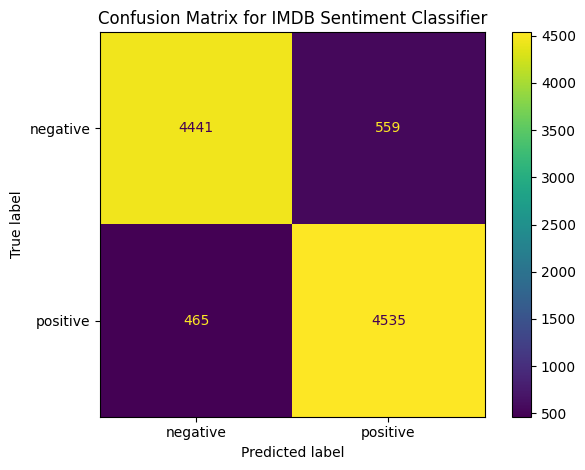

In [16]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative", "positive"]
)

disp.plot(values_format="d")
plt.title("Confusion Matrix for IMDB Sentiment Classifier")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=300)
plt.show()


## 14. Save Prediction Results

This table stores the original test reviews, true labels, and predicted labels.


In [17]:
results_df = pd.DataFrame({
    "review": X_test,
    "true_label": y_test,
    "predicted_label": y_pred
}).reset_index(drop=True)

results_df["true_sentiment"] = results_df["true_label"].map({
    0: "negative",
    1: "positive"
})

results_df["predicted_sentiment"] = results_df["predicted_label"].map({
    0: "negative",
    1: "positive"
})

results_df["correct"] = results_df["true_label"] == results_df["predicted_label"]

results_df.to_csv(os.path.join(OUTPUT_DIR, "all_test_predictions.csv"), index=False)

display(results_df.head())


,review,true_label,predicted_label,true_sentiment,predicted_sentiment,correct
0,"yes, mtv there really is a way to market daria. what started as a clever teenage angst-""comment on everything that sucks and make the viewer feel better abo...",0,0,negative,negative,True
1,"the story of the bride fair is an amusing and engaging one, and it is to the filmmaker's credit that he sets out to portray rural minnesotans with the same ...",0,1,negative,positive,False
2,"a team varied between scully and mulder, two other scientists, a pilot, and the guy who plays bana on seinfeld, go up to an arctic research post where all m...",1,1,positive,positive,True
3,"this was a popular movie probably because of the humor in it, the fast-moving story, an underdog character who shuts up all the loudmouths, etc. funny thing...",0,0,negative,negative,True
4,"this movie made me so angry!! here i am thinking that here's a new horror movie, one w/a sense of intelligence & then the movie starts. the scenery, the del...",0,0,negative,negative,True


## 15. Identify Incorrect Predictions

The assignment asks for five samples that the model got wrong.

The next cells save all incorrect predictions and select five examples for closer discussion.


In [18]:
wrong_df = results_df[results_df["correct"] == False].copy()

print("Number of incorrect predictions:", wrong_df.shape[0])
print("Incorrect prediction rate:", round(wrong_df.shape[0] / results_df.shape[0], 4))

wrong_df.to_csv(os.path.join(OUTPUT_DIR, "wrong_predictions.csv"), index=False)

display(wrong_df.head())


Number of incorrect predictions: 1024
Incorrect prediction rate: 0.1024


,review,true_label,predicted_label,true_sentiment,predicted_sentiment,correct
1,"the story of the bride fair is an amusing and engaging one, and it is to the filmmaker's credit that he sets out to portray rural minnesotans with the same ...",0,1,negative,positive,False
7,"this movie is really wack. there is really nothing nice i can say about it, besides the moral truth expressed in the film's climax concerning people in the ...",0,1,negative,positive,False
12,i admit creating great expectations before watching because some friends mentioned it (and they are not pervs!) as a must see. and it is a must see! just do...,1,0,positive,negative,False
14,"little quentin seems to have mastered the art of having the cake and eating it. as usual, the pure sadistic display can be explained as a clever thought-pro...",0,1,negative,positive,False
18,"the film listed here as having been made in 1980 is not the film which is available from something weird video in their ""driver's ed scare films vol. 5"". fo...",0,1,negative,positive,False


In [19]:
five_wrong = wrong_df.sample(5, random_state=42).copy()

# Create shorter excerpts for easier Medium table formatting
five_wrong["review_excerpt"] = five_wrong["review"].apply(
    lambda x: x[:500] + "..." if len(x) > 500 else x
)

five_wrong_table = five_wrong[[
    "review_excerpt",
    "true_sentiment",
    "predicted_sentiment"
]].copy()

five_wrong_table["possible_reason_for_error"] = ""

five_wrong_table.to_csv(os.path.join(OUTPUT_DIR, "five_wrong_predictions.csv"), index=False)

display(five_wrong_table)


,review_excerpt,true_sentiment,predicted_sentiment,possible_reason_for_error
5318,"yeah,it's low budget. yeah,it's one of candy's earliest films, but it is maybe his funniest! john candy was not so far removed from his sctv days in ""going ...",positive,negative,
3415,"after watching john preform this one of a kind show, i had to share.....it was really something to watch a grown man portray himself as a child. i like the ...",positive,negative,
4383,the twins effect is a vampire martial arts movie available in cantonese with english subtitles. it is a jackie chan production and he does make a special gu...,positive,negative,
306,"this movie is a great way for the series to finally end. peter (the boy from puppet master iii) is all grown up and is now the puppet master. well, this gir...",positive,negative,
6174,this is the most depressing film i have ever seen. i first saw it as a child and even thinking about it now really upsets me. i know it was set in a time wh...,negative,positive,


## 16. Analyze Top Positive and Negative Words/Phrases

Logistic Regression coefficients can help show which TF-IDF features were most associated with positive or negative predictions.

Important: these words are associated with model predictions. They should not be interpreted as proof that a word directly causes sentiment.


In [20]:
tfidf = model.named_steps["tfidf"]
classifier = model.named_steps["classifier"]

feature_names = np.array(tfidf.get_feature_names_out())
coefficients = classifier.coef_[0]

top_n = 20

top_positive_indices = coefficients.argsort()[-top_n:][::-1]
top_negative_indices = coefficients.argsort()[:top_n]

top_positive_words = pd.DataFrame({
    "word_or_phrase": feature_names[top_positive_indices],
    "coefficient": coefficients[top_positive_indices],
    "associated_sentiment": "positive"
})

top_negative_words = pd.DataFrame({
    "word_or_phrase": feature_names[top_negative_indices],
    "coefficient": coefficients[top_negative_indices],
    "associated_sentiment": "negative"
})

top_words = pd.concat([top_positive_words, top_negative_words], ignore_index=True)
top_words["coefficient"] = top_words["coefficient"].round(4)

top_words.to_csv(os.path.join(OUTPUT_DIR, "top_words.csv"), index=False)

display(top_words)


,word_or_phrase,coefficient,associated_sentiment
0,great,7.2629,positive
1,excellent,6.7691,positive
2,best,5.4178,positive
3,perfect,5.3679,positive
4,amazing,5.1094,positive
5,wonderful,4.9877,positive
6,loved,4.4042,positive
7,hilarious,4.4007,positive
8,fun,4.2672,positive
9,brilliant,4.2613,positive


In [21]:
# Side-by-side version for Medium formatting
top_words_side_by_side = pd.DataFrame({
    "Top Positive Words/Phrases": top_positive_words["word_or_phrase"].values,
    "Positive Coefficient": top_positive_words["coefficient"].round(4).values,
    "Top Negative Words/Phrases": top_negative_words["word_or_phrase"].values,
    "Negative Coefficient": top_negative_words["coefficient"].round(4).values
})

top_words_side_by_side.to_csv(os.path.join(OUTPUT_DIR, "top_words_side_by_side.csv"), index=False)

display(top_words_side_by_side)


,Top Positive Words/Phrases,Positive Coefficient,Top Negative Words/Phrases,Negative Coefficient
0,great,7.2629,worst,-9.5291
1,excellent,6.7691,awful,-7.8322
2,best,5.4178,bad,-7.7250
3,perfect,5.3679,waste,-6.9850
4,amazing,5.1094,boring,-6.4307
5,wonderful,4.9877,poor,-5.8138
6,loved,4.4042,terrible,-5.6217
7,hilarious,4.4007,dull,-5.1584
8,fun,4.2672,worse,-5.1525
9,brilliant,4.2613,poorly,-5.0494


## 17. Optional: Review Length and Error Patterns

This table compares the average review length for correct and incorrect predictions.

This can help you discuss whether long or short reviews were harder for the model.


In [22]:
results_with_length = results_df.copy()
results_with_length["review_length_words"] = results_with_length["review"].apply(lambda x: len(x.split()))

error_length_summary = results_with_length.groupby("correct")["review_length_words"].agg(
    ["count", "mean", "median", "min", "max"]
).reset_index()

error_length_summary["correct"] = error_length_summary["correct"].map({
    True: "Correct predictions",
    False: "Incorrect predictions"
})

error_length_summary.to_csv(os.path.join(OUTPUT_DIR, "error_length_summary.csv"), index=False)

display(error_length_summary)


,correct,count,mean,median,min,max
0,Incorrect predictions,1024,230.928711,173.0,23,2088
1,Correct predictions,8976,227.688168,170.0,6,1808


## 18. Summary for Medium Post

Use these generated files in your Medium post:

- `outputs/class_balance.png`
- `outputs/avg_review_length_by_sentiment.png`
- `outputs/model_metrics.csv`
- `outputs/confusion_matrix.png`
- `outputs/five_wrong_predictions.csv`
- `outputs/top_words_side_by_side.csv`
- `outputs/error_length_summary.csv`

Suggested interpretation:

- If accuracy/F1 are high, the review text contains strong signals for sentiment.
- Incorrect predictions may involve sarcasm, mixed opinions, vague language, negation, or plot summaries with little direct opinion.
- The model is useful for large-scale sentiment monitoring, but it should not replace careful human reading when nuance matters.
